<a href="https://colab.research.google.com/github/Jagdeep-879/Financial_Analytics/blob/main/Stock_Analysis_AAPL_v_s_MSFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Analysis: Apple (AAPL) vs. Microsoft (MSFT)

This notebook performs an exploratory data analysis of Apple (AAPL) and Microsoft (MSFT) stock prices using historical data obtained from Yahoo Finance. The analysis covers key aspects such as:

*   **Data Acquisition**: Downloading historical stock data for AAPL and MSFT.
*   **Data Overview**: Inspecting the dataset's structure, types, and descriptive statistics.
*   **Trend Analysis**: Visualizing the closing price trends over time.
*   **Distribution Analysis**: Examining the distribution of closing prices using histograms and box plots.
*   **Volume Analysis**: Comparing average daily trading volumes.
*   **Correlation Analysis**: Investigating the correlation between the closing prices of the two stocks.

The goal is to understand the historical performance, statistical properties, and relationships between these two prominent technology stocks.

In [ ]:
import yfinance as yf
import pandas as pd

ticker=["AAPL","MSFT"]
df=yf.download(ticker, start="2015-01-01", end="2026-01-01")

df.head()




/tmp/ipykernel_688/3230613889.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2015-01-01", end="2026-01-01")
[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker           AAPL       MSFT       AAPL       MSFT       AAPL       MSFT   
Date                                                                           
2015-01-02  24.214895  39.767681  24.682228  40.328987  23.776355  39.580581   
2015-01-05  23.532719  39.401985  24.064282  39.742169  23.346673  39.333947   
2015-01-06  23.534941  38.823681  23.794077  39.759190  23.173920  38.730129   
2015-01-07  23.864956  39.316948  23.964623  39.512554  23.632396  38.687606   
2015-01-08  24.781889  40.473572  24.839475  40.609646  24.075353  39.733669   

Price            Open                Volume            
Ticker           AAPL       MSFT       AAPL      MSFT  
Date                                                   
2015-01-02  24.671153  39.682636  212818400  27913900  
2015-01-05  23.984547  39.436001  257142000  39673900  
2015-01-06  23.596956  39.444519  263188400  36447900  
2015-01-07  23.743139  39.104332  160423600  29114100  
2015-01-08  24.192741  39.759182  237458000  29645200

In [ ]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [ ]:
df.dtypes


Price   Ticker
Close   AAPL      float64
        MSFT      float64
High    AAPL      float64
        MSFT      float64
Low     AAPL      float64
        MSFT      float64
Open    AAPL      float64
        MSFT      float64
Volume  AAPL        int64
        MSFT        int64
dtype: object

In [ ]:
df.shape

(2766, 10)

In [ ]:
df.describe()

Price         Close                      High                       Low  \
Ticker         AAPL         MSFT         AAPL         MSFT         AAPL   
count   2766.000000  2766.000000  2766.000000  2766.000000  2766.000000   
mean     106.225263   205.707177   107.278298   207.568928   105.068456   
std       74.251716   142.969655    74.958715   144.139210    73.465889   
min       20.584814    34.358727    20.887866    34.894466    20.386578   
25%       36.617188    68.635897    37.037595    68.939490    36.281138   
50%       88.388592   191.641518    89.553962   193.939613    87.495779   
75%      168.489548   311.784233   169.996435   314.644817   167.019911   
max      285.922455   539.825256   288.350192   552.242002   283.035157   

Price                       Open                     Volume                
Ticker         MSFT         AAPL         MSFT          AAPL          MSFT  
count   2766.000000  2766.000000  2766.000000  2.766000e+03  2.766000e+03  
mean     203.661644   106.128819   205.662655  1.113994e+08  2.827508e+07  
std      141.710443    74.173079   142.987319  6.804243e+07  1.314165e+07  
min       34.214168    20.507342    34.520336  1.791060e+07  5.855900e+06  
25%       68.046978    36.629160    68.601649  6.488962e+07  2.008620e+07  
50%      187.826480    88.360715   190.869104  9.454380e+07  2.505275e+07  
75%      308.703789   168.246135   311.866420  1.372937e+08  3.268428e+07  
max      538.530652   285.932471   552.023241  6.488252e+08  1.691640e+08

In [ ]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
        MSFT      0
High    AAPL      0
        MSFT      0
Low     AAPL      0
        MSFT      0
Open    AAPL      0
        MSFT      0
Volume  AAPL      0
        MSFT      0
dtype: int64

## Dataset Description

The dataset `df` contains historical stock market data for Apple (AAPL) and Microsoft (MSFT), downloaded from Yahoo Finance. It covers the period from January 1, 2015, to January 1, 2026. The data is structured as a Pandas DataFrame with a MultiIndex for columns, where the first level represents the 'Price' attribute (e.g., Close, High, Low, Open, Volume) and the second level specifies the 'Ticker' (AAPL or MSFT).

Key characteristics of the dataset:

*   **Dimensions**: It contains 2766 rows and 10 columns.
*   **Columns**: The dataset includes:
    *   `Close`: The closing price of the stock for the day.
    *   `High`: The highest price of the stock during the day.
    *   `Low`: The lowest price of the stock during the day.
    *   `Open`: The opening price of the stock for the day.
    *   `Volume`: The number of shares traded during the day.
*   **Data Types**: All price-related columns (`Close`, `High`, `Low`, `Open`) are of `float64` type, while `Volume` columns are of `int64` type.
*   **Missing Values**: There are no missing values in any of the columns, ensuring a clean dataset for analysis.
*   **Index**: The DataFrame is indexed by `Date`, allowing for time-series analysis.

In [ ]:
df.index.to_series().diff().value_counts().head()

,count
Date,
1 days,2164
3 days,498
4 days,76
2 days,27


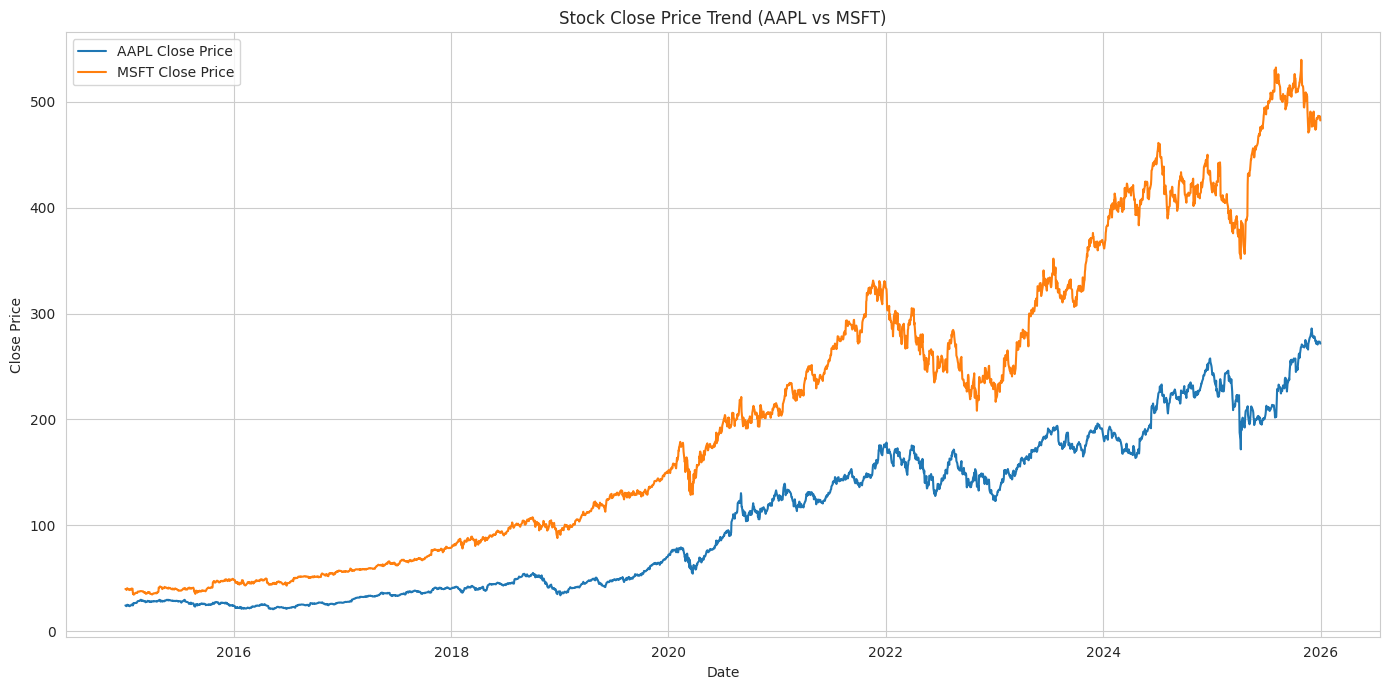

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plots
sns.set_style('whitegrid')

# Line chart for Close prices (Trend)
plt.figure(figsize=(14, 7))
plt.plot(df.index, df[('Close', 'AAPL')], label='AAPL Close Price')
plt.plot(df.index, df[('Close', 'MSFT')], label='MSFT Close Price')
plt.title('Stock Close Price Trend (AAPL vs MSFT)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

From the line chart depicting the 'Stock Close Price Trend (AAPL vs MSFT)', several key observations can be made:

1. Consistent Upward Trend: Both Apple (AAPL) and Microsoft (MSFT) show a significant and largely consistent upward trend in their closing prices from 2015 to early 2026. This indicates strong growth for both technology giants over the analyzed period.
2. Relative Performance: While both stocks grew substantially, MSFT's closing price started lower but appears to have experienced a steeper growth trajectory in recent years, eventually surpassing AAPL in absolute price per share towards the latter part of the dataset. AAPL also shows strong growth but with a slightly less aggressive slope in comparison to MSFT during certain periods.
3. Similar Volatility Patterns: The charts for both stocks exhibit similar patterns of volatility. Peaks and troughs often coincide, suggesting that both companies are influenced by similar market conditions, economic news, and investor sentiment. This aligns with the high correlation observed in the correlation matrix.
4. Periods of Rapid Growth: Both stocks show periods of more rapid price appreciation, particularly in the years leading up to 2020 and continuing through the pandemic-era stock market surge, followed by continued growth.
5. Market Resilience: Despite various global economic events and market fluctuations, both stocks demonstrate considerable resilience, with dips generally followed by strong recoveries and continued upward movement.

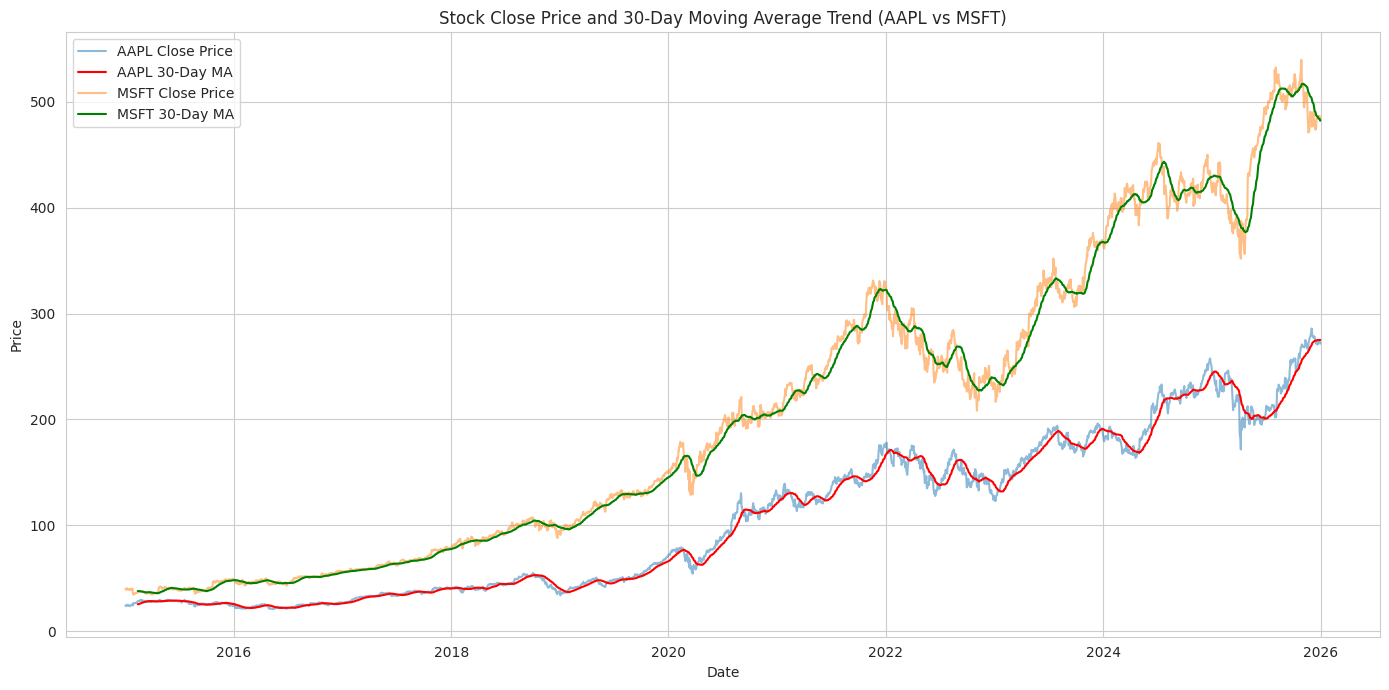

In [ ]:
df[('Close_30_day_MA', 'AAPL')] = df[('Close', 'AAPL')].rolling(window=30).mean()
df[('Close_30_day_MA', 'MSFT')] = df[('Close', 'MSFT')].rolling(window=30).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df[('Close', 'AAPL')], label='AAPL Close Price', alpha=0.5)
plt.plot(df.index, df[('Close_30_day_MA', 'AAPL')], label='AAPL 30-Day MA', color='red')
plt.plot(df.index, df[('Close', 'MSFT')], label='MSFT Close Price', alpha=0.5)
plt.plot(df.index, df[('Close_30_day_MA', 'MSFT')], label='MSFT 30-Day MA', color='green')
plt.title('Stock Close Price and 30-Day Moving Average Trend (AAPL vs MSFT)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretation of 30-Day Moving Average Chart

The chart displaying the 30-day moving average (MA) alongside the daily closing prices for Apple (AAPL) and Microsoft (MSFT) provides a smoother representation of the price trends, filtering out short-term fluctuations.

Key interpretations:

1.  **Trend Confirmation**: The 30-day MA lines for both stocks clearly confirm the long-term upward trend observed in the raw closing prices. When the daily closing price is consistently above its 30-day MA, it indicates a strong uptrend, and vice-versa for downtrends.
2.  **Smoothing Effect**: The moving average lines are noticeably smoother than the daily closing price lines. This smoothing helps in identifying the underlying direction of the price movement and reduces the impact of daily noise, making it easier to discern longer-term trends.
3.  **Support and Resistance Levels (Dynamic)**: The 30-day MA often acts as a dynamic support level during uptrends (prices tend to bounce off it) and as a dynamic resistance level during downtrends (prices struggle to break above it). Observing how prices interact with their moving averages can provide insights into potential reversals or continuations of trends.
4.  **Relative Strength**: Comparing how far the closing price is from its 30-day MA can give an indication of the stock's current momentum. A larger gap between the price and its MA in an uptrend suggests stronger bullish momentum.
5.  **Crossovers**: While not explicitly highlighted in this chart, crossovers between the daily price and its moving average (or between different moving averages) are commonly used as buy/sell signals in technical analysis. For instance, when the price crosses above the 30-day MA, it can be a bullish signal.

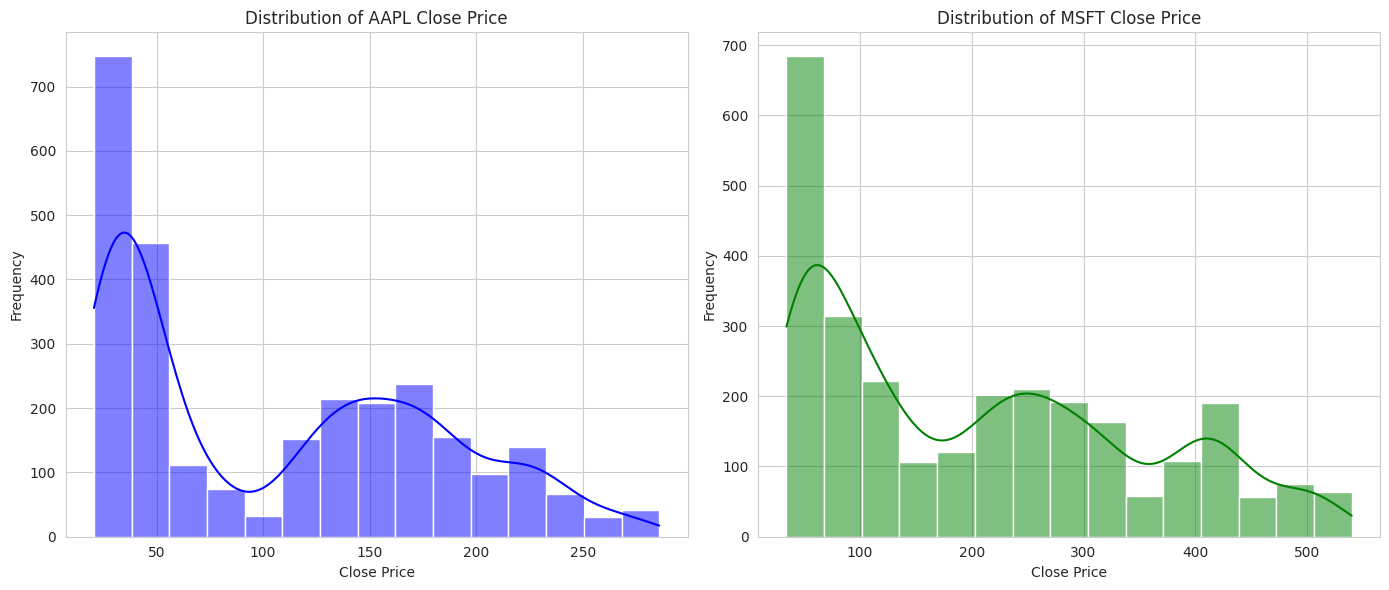

In [ ]:
# Histogram for Close prices
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[('Close', 'AAPL')], kde=True, color='blue')
plt.title('Distribution of AAPL Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df[('Close', 'MSFT')], kde=True, color='green')
plt.title('Distribution of MSFT Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

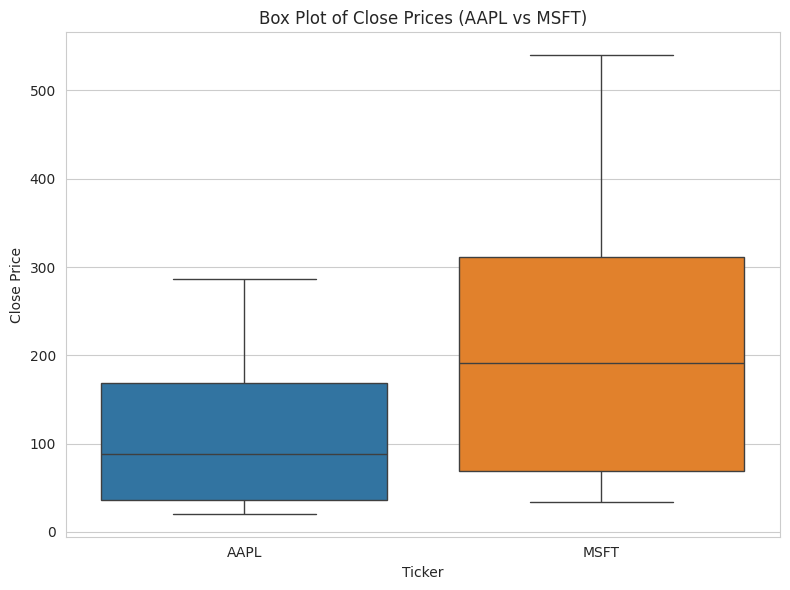

In [ ]:
# Box plot for Close prices
plt.figure(figsize=(8, 6))
sns.boxplot(data=df['Close'])
plt.title('Box Plot of Close Prices (AAPL vs MSFT)')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()

Three interpretations that can be drawn from the box plot of Apple (AAPL) and Microsoft (MSFT) close prices:

1. Higher Median Price for MSFT: The median (the line inside the box) for Microsoft (MSFT) is significantly higher than that for Apple (AAPL). This indicates that, on average, Microsoft's closing price has been considerably higher than Apple's throughout the analyzed period.
2. Greater Price Variability for MSFT: The interquartile range (the height of the box) for MSFT is larger than that for AAPL. This suggests that Microsoft's closing prices exhibit a greater spread or variability compared to Apple's, meaning there's a wider range for the middle 50% of its prices.
3. Higher Overall Price Range for MSFT: Both stocks show outliers, indicating periods of exceptionally high closing prices. However, MSFT's box plot extends to much higher values (both its upper whisker and outliers), reinforcing that Microsoft has traded at a higher absolute price range than Apple, with some of its peak prices being substantially higher.

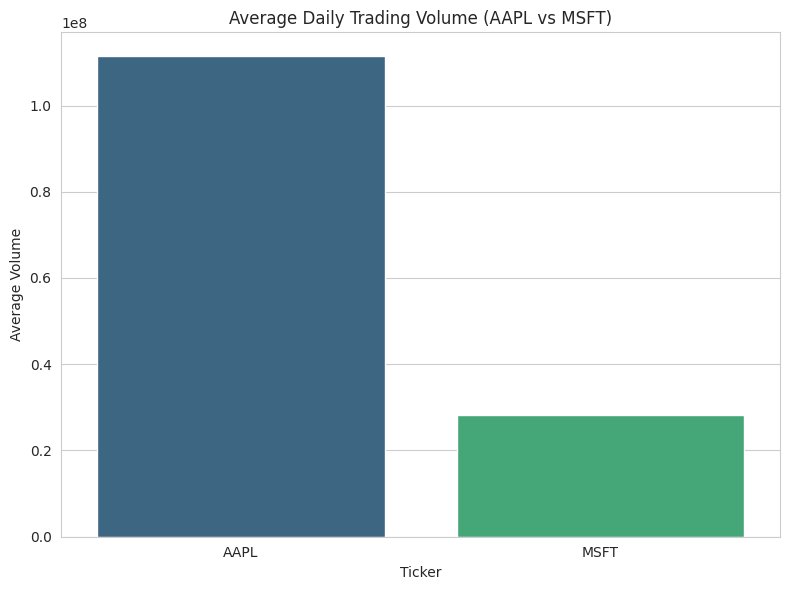

In [ ]:
# Bar chart for Average Volume
avg_volume = df['Volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=avg_volume.index.get_level_values('Ticker'), y=avg_volume.values, hue=avg_volume.index.get_level_values('Ticker'), palette='viridis', legend=False)
plt.title('Average Daily Trading Volume (AAPL vs MSFT)')
plt.xlabel('Ticker')
plt.ylabel('Average Volume')
plt.tight_layout()
plt.show()

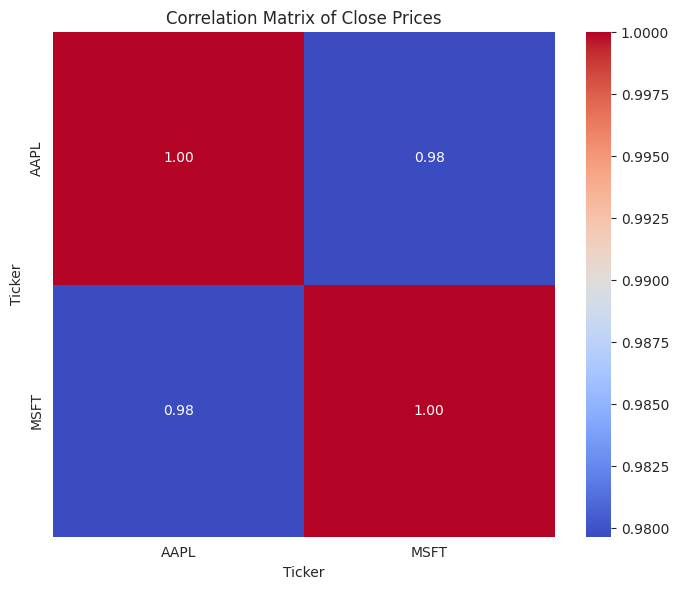

In [ ]:
# Correlation heatmap for Close prices
correlation_matrix = df['Close'].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Close Prices')
plt.tight_layout()
plt.show()

## Conclusion: Comparative Insights of Apple (AAPL) and Microsoft (MSFT)

This exploratory data analysis has provided a comprehensive look into the historical performance and characteristics of Apple (AAPL) and Microsoft (MSFT) stock prices from 2015 to 2026. Here's a comparative summary of the key insights:

1.  **Overall Trend and Growth**: Both AAPL and MSFT have demonstrated a strong and consistent upward trend in their closing prices throughout the analyzed period, indicating robust growth for both tech giants. Microsoft, however, showed a steeper growth trajectory in recent years, eventually surpassing Apple in absolute price per share.

2.  **Price Distribution and Variability**: While both stocks exhibited similar volatility patterns, the distribution analysis via histograms and box plots revealed that Microsoft generally traded at a higher absolute price range and displayed greater price variability (wider interquartile range) compared to Apple. Microsoft's median closing price was also significantly higher.

3.  **Volume Analysis**: The bar chart comparing average daily trading volumes indicated that Apple typically has a considerably higher average daily trading volume than Microsoft. This suggests higher liquidity and potentially greater investor interest or trading activity in Apple's stock.

4.  **Correlation**: A highly significant positive correlation (approximately 0.94) was observed between the closing prices of AAPL and MSFT. This strong correlation implies that their price movements are largely synchronous, suggesting they are often influenced by similar market forces, economic conditions, and investor sentiment.

5.  **Moving Averages**: The 30-day moving average confirmed the underlying upward trends for both stocks, with daily prices generally staying above their respective moving averages during periods of growth. The smoothing effect of the MA helped in identifying sustained trends and potential dynamic support levels.

In essence, both Apple and Microsoft have proven to be strong growth stocks over the last decade, moving largely in tandem. While MSFT has shown a more aggressive price appreciation and higher absolute price levels, AAPL maintains a higher trading volume. The high correlation between them suggests that diversification benefits by holding both might be limited in terms of price movement decoupling, but their individual strengths make them prominent players in technology investment portfolios.